# Capítulo 5 — Separar datos: entrenamiento y prueba

En el cuaderno anterior organizamos la información en variables de entrada (`X`) y variable objetivo (`y`). Ahora daremos el paso siguiente: dividir esos datos para que una parte se use durante el aprendizaje y otra permanezca reservada para evaluar el modelo con casos no vistos.

El objetivo de este cuaderno no es entrenar ni comparar modelos. Nos concentraremos en comprender qué produce `train_test_split`, cómo elegir una proporción, para qué sirve `random_state` y por qué la estratificación es importante en clasificación.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar por qué no conviene entrenar y evaluar con los mismos casos;
- obtener `X_train`, `X_test`, `y_train` e `y_test`;
- comprobar que las entradas y las respuestas conservan su correspondencia;
- comparar divisiones 80/20 y 70/30;
- usar `random_state` para reproducir una separación;
- aplicar estratificación y revisar la distribución de las clases.

## 1. Importar las herramientas

Usaremos `pandas` y `matplotlib`, junto con dos elementos de `scikit-learn`: un dataset clásico y la función `train_test_split`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

## 2. Cargar el dataset y construir `X` e `y`

Trabajaremos con el dataset Wine incluido en `scikit-learn`. Cada fila corresponde al análisis químico de una muestra de vino. Las variables de entrada contienen distintas mediciones y la variable objetivo identifica uno de tres cultivares.

No necesitamos estudiar en detalle cada medición: en este capítulo nos interesa cómo se organizan y se separan los casos.

In [3]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["cultivar"] = pd.Series(wine.target).map({
    0: "Cultivar 0",
    1: "Cultivar 1",
    2: "Cultivar 2",
})

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,Cultivar 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,Cultivar 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,Cultivar 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,Cultivar 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,Cultivar 0


El DataFrame reúne las mediciones químicas y la categoría de cada muestra. Como `cultivar` contiene categorías, estamos frente a un problema de clasificación multiclase.

Separaremos las mediciones de la variable objetivo, igual que hicimos en el cuaderno anterior.

In [4]:
X = df.drop(columns="cultivar")
y = df["cultivar"]

print(f"Forma de X: {X.shape}")
print(f"Cantidad de valores en y: {y.shape[0]}")

Forma de X: (178, 13)
Cantidad de valores en y: 178


`X` contiene 178 muestras y 13 variables de entrada. `y` contiene las 178 respuestas correspondientes. Antes de dividir, observemos cuántos casos pertenecen a cada clase.

In [5]:
y.value_counts().sort_index()

,count
cultivar,
Cultivar 0,59
Cultivar 1,71
Cultivar 2,48


Las tres clases están representadas, pero no tienen exactamente la misma cantidad de ejemplos. `Cultivar 1` es la clase más frecuente y `Cultivar 2`, la menos frecuente. Esta distribución será importante cuando estudiemos la estratificación.

## 3. Hacer una primera separación

Usaremos el 80% de los datos para entrenamiento y reservaremos el 20% para prueba. Todavía no agregaremos estratificación, porque primero queremos observar qué hace una división aleatoria básica.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

La función devuelve cuatro objetos. Podemos revisar sus tamaños para interpretar el resultado de la separación.

In [7]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (142, 13)
X_test:  (36, 13)
y_train: (142,)
y_test:  (36,)


Quedaron 142 muestras para entrenamiento y 36 para prueba. Los tamaños de `X_train` e `y_train` coinciden entre sí, al igual que los de `X_test` e `y_test`.

El 20% de 178 no es un número entero, por lo que la cantidad final de filas debe ajustarse a casos completos. Por eso hablamos de una proporción aproximada.

También podemos verificar que una misma fila no haya quedado simultáneamente en entrenamiento y prueba.

In [8]:
indices_compartidos = X_train.index.intersection(X_test.index)

print(f"Cantidad de índices compartidos: {len(indices_compartidos)}")
print(f"Total de filas después de separar: {len(X_train) + len(X_test)}")

Cantidad de índices compartidos: 0
Total de filas después de separar: 178


No hay índices compartidos y la suma de ambos conjuntos vuelve a dar 178. Cada muestra quedó en una sola parte: entrenamiento o prueba.

Reservar casos significa justamente impedir que participen del aprendizaje. Más adelante, el modelo recibirá `X_test` sin haber utilizado esas filas para ajustarse.

## 4. Comprobar la correspondencia entre `X` e `y`

`train_test_split` mezcla las filas, pero mantiene alineada cada entrada con su respuesta. Podemos comprobarlo observando los primeros índices del conjunto de prueba.

In [9]:
comparacion_prueba = X_test[["alcohol", "malic_acid"]].head().copy()
comparacion_prueba["cultivar_en_y_test"] = y_test.head()

comparacion_prueba

,alcohol,malic_acid,cultivar_en_y_test
19,13.64,3.10,Cultivar 0
45,14.21,4.04,Cultivar 0
140,12.93,2.81,Cultivar 2
30,13.73,1.50,Cultivar 0
67,12.37,1.17,Cultivar 1


Los índices no son consecutivos porque las filas fueron mezcladas antes de dividir. Sin embargo, cada valor de `y_test` conserva el índice de la muestra correspondiente en `X_test`.

In [10]:
print("¿Coinciden los índices de entrenamiento?:", X_train.index.equals(y_train.index))
print("¿Coinciden los índices de prueba?:", X_test.index.equals(y_test.index))

¿Coinciden los índices de entrenamiento?: True
¿Coinciden los índices de prueba?: True


Ambas comprobaciones devuelven `True`. Esto es esencial: si las filas de `X` y los valores de `y` se desalinearan, cada muestra quedaría asociada con una respuesta incorrecta.

## 5. Comparar proporciones habituales

Las divisiones 80/20 y 70/30 son puntos de partida frecuentes, pero no reglas universales. Veamos cuántos casos produce cada una en este dataset.

> Estas proporciones son ejemplos habituales, no reglas obligatorias. En problemas reales, la elección depende del tamaño del dataset, del objetivo del análisis y de cuántos casos necesitamos reservar para obtener una evaluación razonable.

In [11]:
resultados_proporciones = []

for proporcion_prueba in [0.2, 0.3]:
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
        X,
        y,
        test_size=proporcion_prueba,
        random_state=42
    )

    resultados_proporciones.append({
        "división": f"{int((1 - proporcion_prueba) * 100)}/{int(proporcion_prueba * 100)}",
        "filas_entrenamiento": len(X_entrenamiento),
        "filas_prueba": len(X_prueba),
    })

pd.DataFrame(resultados_proporciones)

,división,filas_entrenamiento,filas_prueba
0,80/20,142,36
1,70/30,124,54


Con una división 80/20, el modelo dispondría de más ejemplos para aprender y la prueba sería más pequeña. Con 70/30, se reservan más casos para evaluar, pero quedan menos para entrenamiento.

La elección depende del tamaño del dataset y del problema. En conjuntos pequeños, cada fila reservada reduce la información disponible para aprender; al mismo tiempo, una prueba demasiado pequeña puede producir una evaluación poco representativa.

## 6. Controlar la aleatoriedad con `random_state`

La función mezcla los casos antes de dividirlos. Si fijamos el mismo `random_state`, podemos repetir exactamente la separación.

In [12]:
_, X_test_a, _, y_test_a = train_test_split(
    X, y, test_size=0.2, random_state=42
)

_, X_test_b, _, y_test_b = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("¿Las dos pruebas tienen los mismos índices?:", X_test_a.index.equals(X_test_b.index))
print("Primeros índices:", X_test_a.index[:10].tolist())

¿Las dos pruebas tienen los mismos índices?: True
Primeros índices: [19, 45, 140, 30, 67, 16, 119, 174, 109, 141]


Las dos ejecuciones produjeron exactamente el mismo conjunto de prueba. Esto vuelve reproducible el experimento: otra persona que use los mismos datos y parámetros podrá obtener la misma división.

El número `42` no tiene una propiedad especial. Podríamos elegir otro entero; lo importante es mantenerlo fijo cuando necesitamos repetir o comparar un procedimiento.

Si cambiamos la semilla, la proporción seguirá siendo 80/20, pero cambiarán las muestras asignadas a cada conjunto.

In [13]:
_, X_test_c, _, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=7
)

print("¿Las semillas 42 y 7 producen la misma prueba?:", X_test_a.index.equals(X_test_c.index))
print("Primeros índices con semilla 7:", X_test_c.index[:10].tolist())

¿Las semillas 42 y 7 producen la misma prueba?: False
Primeros índices con semilla 7: [147, 36, 167, 171, 126, 133, 102, 32, 120, 143]


El resultado es `False`: cambiar `random_state` modifica qué filas quedan reservadas. Esto no significa que debamos probar semillas hasta encontrar la que produzca el resultado más favorable. La semilla controla la reproducibilidad; no es una herramienta para elegir una prueba conveniente.

## 7. Observar la distribución de las clases

En clasificación, una separación aleatoria puede modificar las proporciones de las clases. Compararemos el dataset completo con el conjunto de prueba obtenido sin estratificación.

In [14]:
distribucion_sin_estratificar = pd.concat(
    [
        y.value_counts(normalize=True).mul(100).rename("Dataset completo"),
        y_test.value_counts(normalize=True).mul(100).rename("Prueba sin estratificar"),
    ],
    axis=1
).sort_index().round(1)

distribucion_sin_estratificar

,Dataset completo,Prueba sin estratificar
cultivar,,
Cultivar 0,33.1,38.9
Cultivar 1,39.9,38.9
Cultivar 2,27.0,22.2


La división mantiene las tres clases, pero sus proporciones cambiaron. Por ejemplo, `Cultivar 0` representa el 33,1% del dataset completo y el 38,9% de la prueba; `Cultivar 2` baja del 27,0% al 22,2%.

La diferencia surgió por azar. No es un error de la función: al seleccionar una cantidad limitada de filas, las proporciones pueden variar.

## 8. Separar con estratificación

En un problema de clasificación podemos pedir que la división conserve aproximadamente la distribución de `y`. Para hacerlo usamos `stratify=y`.

In [15]:
X_train_est, X_test_est, y_train_est, y_test_est = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Comparemos las proporciones del dataset completo, la prueba sin estratificar y la prueba estratificada.

In [16]:
comparacion_distribuciones = pd.concat(
    [
        y.value_counts(normalize=True).mul(100).rename("Dataset completo"),
        y_test.value_counts(normalize=True).mul(100).rename("Prueba sin estratificar"),
        y_test_est.value_counts(normalize=True).mul(100).rename("Prueba estratificada"),
    ],
    axis=1
).sort_index().round(1)

comparacion_distribuciones

,Dataset completo,Prueba sin estratificar,Prueba estratificada
cultivar,,,
Cultivar 0,33.1,38.9,33.3
Cultivar 1,39.9,38.9,38.9
Cultivar 2,27.0,22.2,27.8


La prueba estratificada queda mucho más cerca de la distribución original. Las proporciones no son idénticas porque solo podemos repartir muestras completas, pero las tres clases conservan una representación semejante a la del dataset.

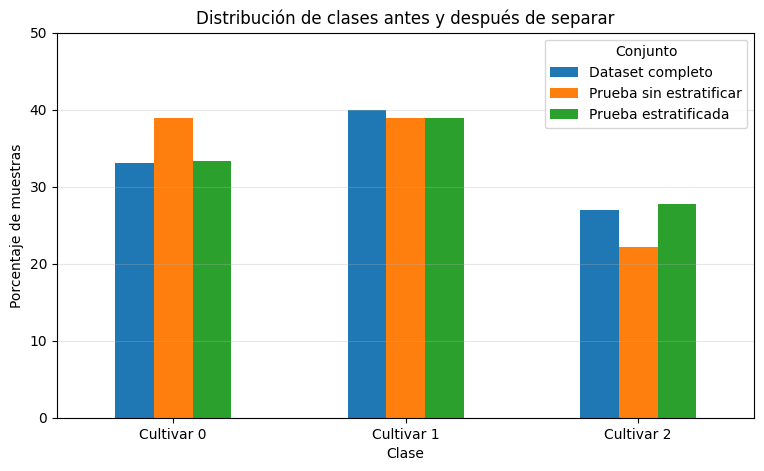

In [17]:
comparacion_distribuciones.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Distribución de clases antes y después de separar")
plt.xlabel("Clase")
plt.ylabel("Porcentaje de muestras")
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Conjunto")
plt.show()

El gráfico permite ver que las barras de la prueba estratificada se aproximan más a las del dataset completo. La estratificación no equilibra las clases ni crea casos nuevos: conserva, dentro de lo posible, las proporciones que ya existen.

También debemos comprobar que la distribución se mantiene en el conjunto de entrenamiento.

In [18]:
distribucion_final = pd.concat(
    [
        y.value_counts(normalize=True).mul(100).rename("Dataset completo"),
        y_train_est.value_counts(normalize=True).mul(100).rename("Entrenamiento"),
        y_test_est.value_counts(normalize=True).mul(100).rename("Prueba"),
    ],
    axis=1
).sort_index().round(1)

distribucion_final

,Dataset completo,Entrenamiento,Prueba
cultivar,,,
Cultivar 0,33.1,33.1,33.3
Cultivar 1,39.9,40.1,38.9
Cultivar 2,27.0,26.8,27.8


Tanto entrenamiento como prueba mantienen proporciones cercanas a las originales. Esto ofrece a ambos conjuntos ejemplos de las tres clases y reduce el riesgo de que una categoría quede representada de manera accidentalmente pobre.

La estratificación ayuda a organizar la división, pero no resuelve por sí sola todos los problemas relacionados con clases poco frecuentes.

## 9. Interpretar el papel de cada conjunto

La división final ya está preparada. Antes de continuar, conviene dejar claro qué función cumplirá cada objeto.

In [19]:
papel_conjuntos = pd.DataFrame({
    "objeto": ["X_train_est", "y_train_est", "X_test_est", "y_test_est"],
    "contenido": [
        "Variables de entrada de entrenamiento",
        "Respuestas del entrenamiento",
        "Variables de entrada de prueba",
        "Respuestas reales reservadas",
    ],
    "uso": [
        "El modelo aprende",
        "Guían el aprendizaje",
        "El modelo genera predicciones",
        "Se comparan con las predicciones",
    ]
})

papel_conjuntos

,objeto,contenido,uso
0,X_train_est,Variables de entrada de entrenamiento,El modelo aprende
1,y_train_est,Respuestas del entrenamiento,Guían el aprendizaje
2,X_test_est,Variables de entrada de prueba,El modelo genera predicciones
3,y_test_est,Respuestas reales reservadas,Se comparan con las predicciones


`X_train_est` e `y_train_est` se usarán juntos durante el entrenamiento. `X_test_est` se entregará al modelo después de entrenarlo y `y_test_est` permitirá comparar las predicciones con las respuestas reales.

En este cuaderno no haremos esos pasos. Mantener la prueba reservada es precisamente la práctica que estamos aprendiendo.

## Actividad breve

Modificá `proporcion_prueba_actividad` y `semilla_actividad`. Observá cómo cambian los tamaños y los índices. Como usamos `stratify=y`, las proporciones de las clases deberían mantenerse razonablemente cercanas a las originales.

In [20]:
proporcion_prueba_actividad = 0.25
semilla_actividad = 7

X_train_act, X_test_act, y_train_act, y_test_act = train_test_split(
    X,
    y,
    test_size=proporcion_prueba_actividad,
    random_state=semilla_actividad,
    stratify=y
)

print(f"Filas de entrenamiento: {len(X_train_act)}")
print(f"Filas de prueba: {len(X_test_act)}")
print("Primeros índices de prueba:", X_test_act.index[:10].tolist())
print("\nDistribución porcentual en la prueba:")
print(y_test_act.value_counts(normalize=True).sort_index().mul(100).round(1))

Filas de entrenamiento: 133
Filas de prueba: 45
Primeros índices de prueba: [167, 125, 92, 61, 116, 3, 68, 77, 172, 25]

Distribución porcentual en la prueba:
cultivar
Cultivar 0    33.3
Cultivar 1    40.0
Cultivar 2    26.7
Name: proportion, dtype: float64


Con los valores iniciales de la actividad, la salida muestra cuántas muestras quedaron para entrenamiento y cuántas para prueba. Si cambiás la proporción, esos tamaños cambiarán. Si cambiás la semilla, cambiarán los índices seleccionados.

Como usamos `stratify=y`, la distribución de clases debería mantenerse razonablemente cercana a la distribución original.

La actividad sirve para observar el mecanismo, no para buscar una división que favorezca un resultado futuro.

## Cierre del cuaderno

En este cuaderno separamos `X` e `y` en conjuntos de entrenamiento y prueba. Comprobamos que no comparten filas, que las entradas conservan su correspondencia con las respuestas y que las proporciones elegidas determinan cuántos casos quedan disponibles para cada función.

También vimos que `random_state` permite repetir la misma división y que cambiarlo modifica las filas seleccionadas. Finalmente, usamos `stratify=y` para conservar aproximadamente la distribución de las clases en un problema de clasificación.

Todavía no entrenamos ni evaluamos un modelo. Antes de hacerlo, los datos pueden necesitar limpieza y transformación. Lo importante es que ya contamos con una separación metodológicamente más honesta: una parte para aprender y otra para comprobar el comportamiento frente a casos no vistos.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Por qué evaluar con los mismos datos usados para entrenar puede producir una impresión engañosa?
2. ¿Qué información contiene cada uno de los cuatro objetos que devuelve `train_test_split`?
3. ¿Qué equilibrio intentamos lograr al elegir una proporción como 80/20 o 70/30?
4. ¿Qué cambia y qué se mantiene cuando usamos otro valor de `random_state`?
5. ¿Por qué no conviene probar semillas hasta encontrar la división más favorable?
6. ¿Qué conserva la estratificación y qué problema no resuelve por sí sola?